In [2]:
# 03_spatial_analysis.ipynb
# Spatial analysis of high-risk vertebrate populations
# Living Planet Database 2024

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Project paths
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load population-level trend dataset
# This should be the dataset created in 01_population_trend_calculation.ipynb
trend_data = pd.read_csv(DATA_DIR / "processed" / "lpd_population_trends_with_risk.csv")

# Basic check
print("Dataset shape:", trend_data.shape)
print("\nColumns:")
print(trend_data.columns.tolist())

# Required columns for spatial risk analysis
required_cols = [
    "ID",
    "Binomial",
    "Class",
    "Region",
    "System",
    "Latitude",
    "Longitude",
    "First_Year",
    "Last_Year",
    "Years_Monitored",
    "Trend",
    "Log_Trend",
    "Risk_Category"
]

missing_cols = [col for col in required_cols if col not in trend_data.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Coordinate cleaning
trend_data["Latitude"] = pd.to_numeric(trend_data["Latitude"], errors="coerce")
trend_data["Longitude"] = pd.to_numeric(trend_data["Longitude"], errors="coerce")

spatial_data = trend_data.dropna(subset=["Latitude", "Longitude"]).copy()

# Keep only valid coordinate ranges
spatial_data = spatial_data[
    spatial_data["Latitude"].between(-90, 90) &
    spatial_data["Longitude"].between(-180, 180)
].copy()

print("\nSpatial dataset shape:", spatial_data.shape)
print("\nRisk category counts:")
print(spatial_data["Risk_Category"].value_counts())

print("\nCoordinate summary:")
display(spatial_data[["Latitude", "Longitude"]].describe())

Dataset shape: (21284, 15)

Columns:
['ID', 'Binomial', 'Class', 'Region', 'System', 'Latitude', 'Longitude', 'First_Year', 'Last_Year', 'First_Population', 'Last_Population', 'Years_Monitored', 'Trend', 'Log_Trend', 'Risk_Category']

Spatial dataset shape: (21284, 15)

Risk category counts:
Risk_Category
Increase                7412
Stable / near stable    5008
Critical decline        4062
Moderate decline        2790
High decline            2012
Name: count, dtype: int64

Coordinate summary:


,Latitude,Longitude
count,21284.000000,21284.000000
mean,12.127286,20.386532
std,38.690690,99.799514
min,-77.850000,-180.000000
25%,-25.101184,-64.848442
50%,13.642100,10.400000
75%,49.652037,135.000000
max,81.000000,180.000000


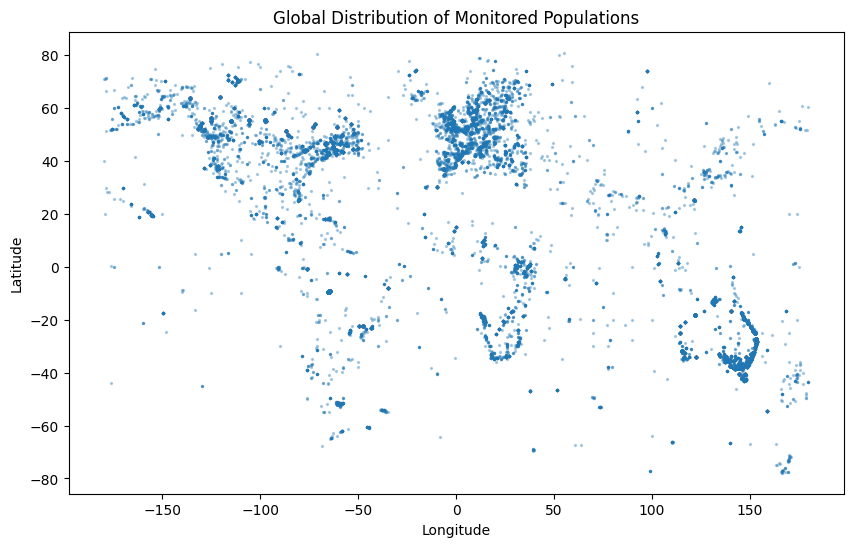

In [3]:
plt.figure(figsize=(10,6))

plt.scatter(
    spatial_data["Longitude"],
    spatial_data["Latitude"],
    s=2,
    alpha=0.3
)

plt.title("Global Distribution of Monitored Populations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [4]:
import geopandas as gpd

# Convert population points into a GeoDataFrame
gdf = gpd.GeoDataFrame(
    spatial_data,
    geometry=gpd.points_from_xy(
        spatial_data["Longitude"],
        spatial_data["Latitude"]
    ),
    crs="EPSG:4326"
)

print(gdf.shape)
gdf.head()

(21284, 16)


,ID,Binomial,Class,Region,System,Latitude,Longitude,First_Year,Last_Year,First_Population,Last_Population,Years_Monitored,Trend,Log_Trend,Risk_Category,geometry
0,1,Balearica_regulorum,Aves,Africa,Terrestrial,-0.07889,31.13306,1985,2002,3.7,10.8,17,1.918919,0.920537,Increase,POINT (31.13306 -0.07889)
1,2,Acrocephalus_sechellensis,Aves,Africa,Terrestrial,-4.33333,55.66667,1958,1987,30.0,430.0,29,13.333333,2.632121,Increase,POINT (55.66667 -4.33333)
2,3,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.66667,1977,1990,38.0,21.0,13,-0.447368,-0.572519,High decline,POINT (55.66667 -4.58333)
3,4,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.93333,1976,1990,46.0,22.0,14,-0.521739,-0.714653,High decline,POINT (55.93333 -4.58333)
4,5,Falco_punctatus,Aves,Africa,Terrestrial,-20.30000,57.58333,1973,1997,1.0,61.0,24,60.000000,3.433987,Increase,POINT (57.58333 -20.30000)


In [6]:
import geopandas as gpd
import fiona

import geodatasets

world = gpd.read_file(
    geodatasets.get_path("naturalearth.land")
)

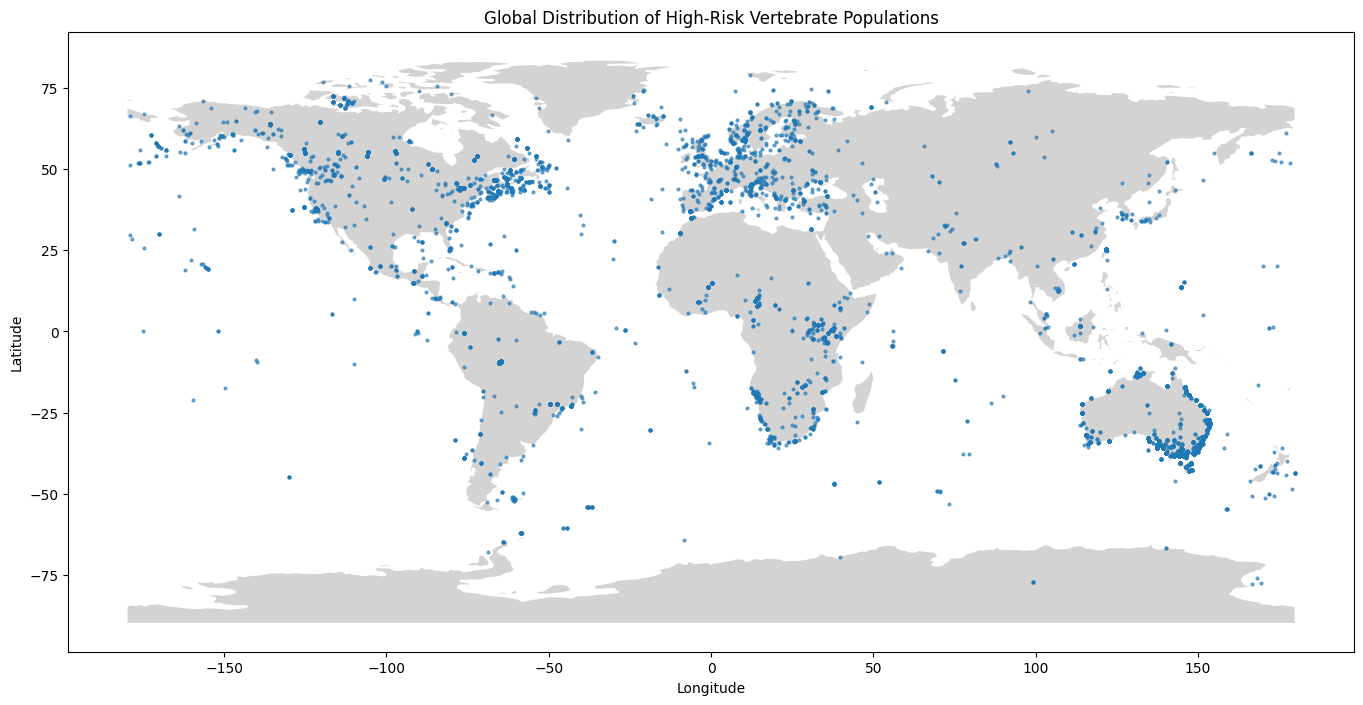

In [7]:
high_risk_gdf = gdf[
    gdf["Risk_Category"].isin(["Critical decline", "High decline"])
].copy()

fig, ax = plt.subplots(figsize=(14, 7))

world.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white"
)

high_risk_gdf.plot(
    ax=ax,
    markersize=4,
    alpha=0.6
)

ax.set_title("Global Distribution of High-Risk Vertebrate Populations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

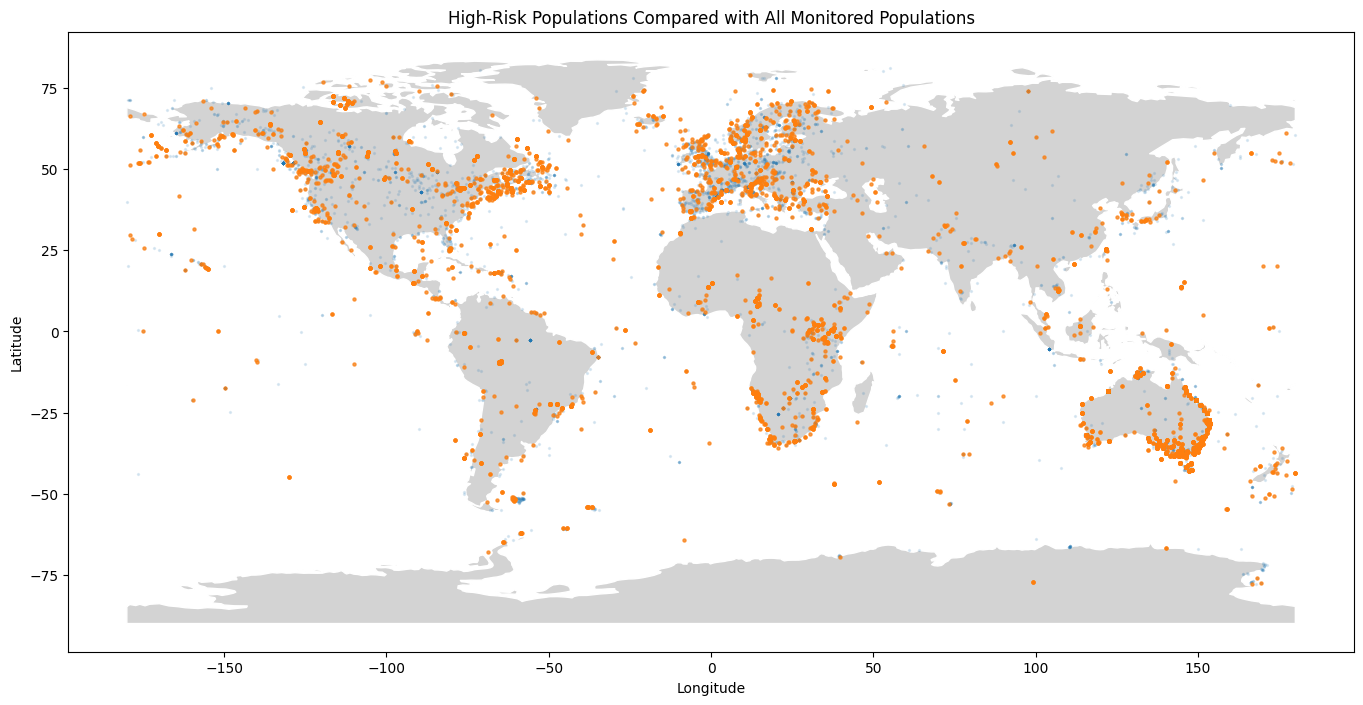

In [9]:
# Compare all monitored populations with high-risk populations

fig, ax = plt.subplots(figsize=(14, 7))

world.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white"
)

# All monitored populations as background
gdf.plot(
    ax=ax,
    markersize=2,
    alpha=0.12
)

# High-risk populations on top
high_risk_gdf.plot(
    ax=ax,
    markersize=5,
    alpha=0.7
)

ax.set_title("High-Risk Populations Compared with All Monitored Populations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/high_risk_vs_all_populations_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

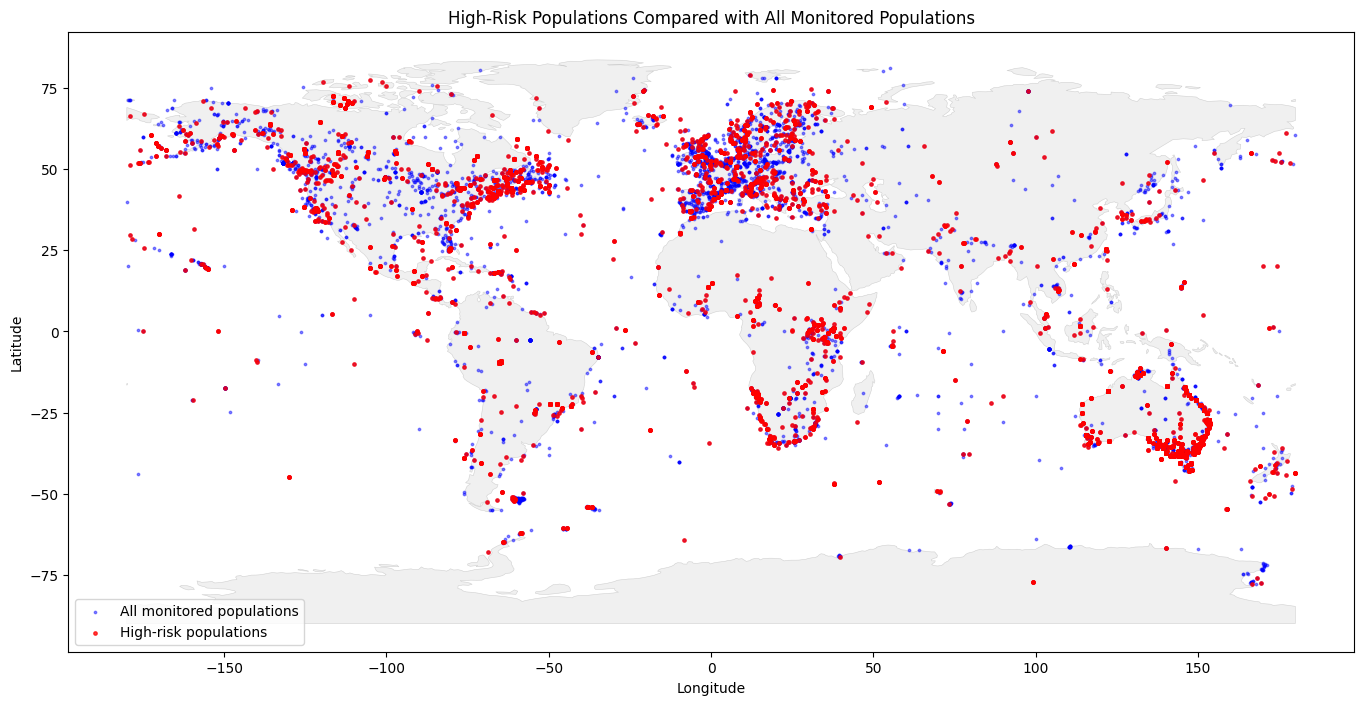

In [12]:
fig, ax = plt.subplots(figsize=(14, 7))

world.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="#d0d0d0",
    linewidth=0.4
)

# All monitored populations as neutral background
gdf.plot(
    ax=ax,
    color="blue",
    markersize=3,
    alpha=0.45,
    label="All monitored populations"
)

# High-risk populations on top
high_risk_gdf.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.75,
    label="High-risk populations"
)

ax.set_title("High-Risk Populations Compared with All Monitored Populations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend(loc="lower left")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/high_risk_vs_all_populations_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

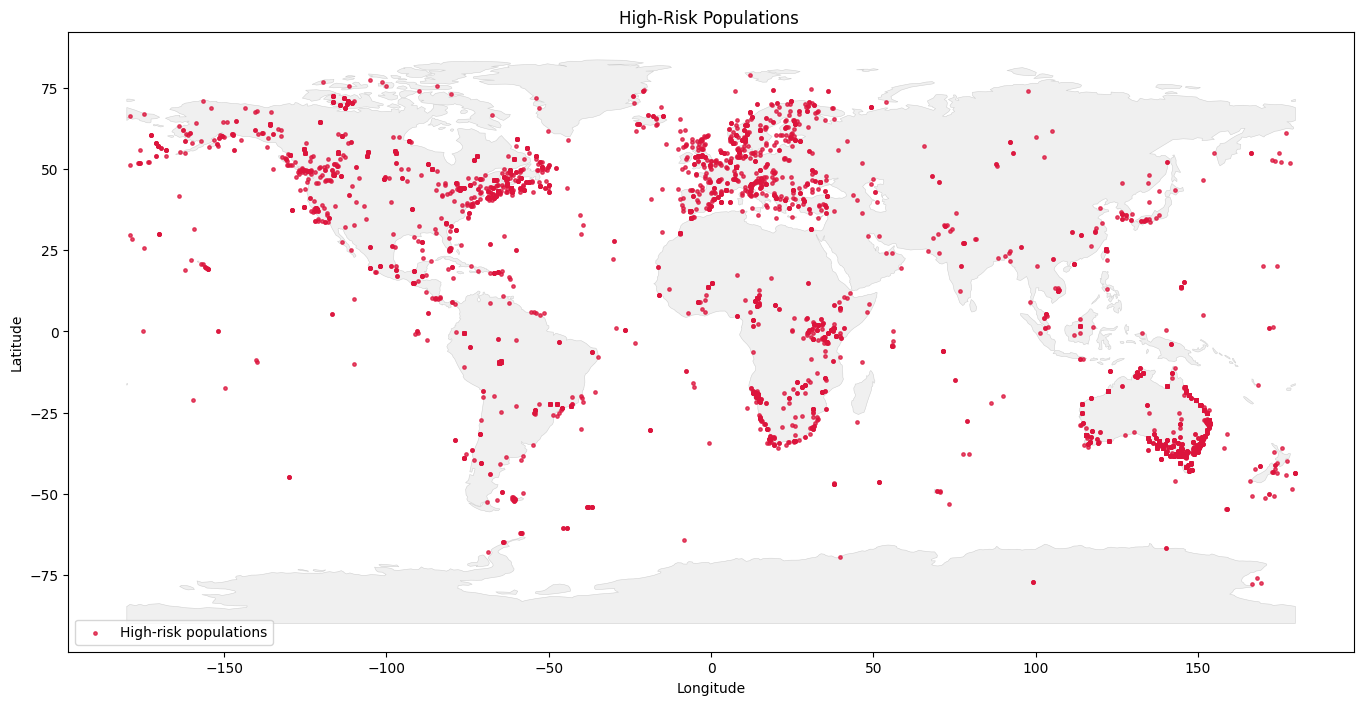

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))

world.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="#d0d0d0",
    linewidth=0.4
)


# High-risk populations on top
high_risk_gdf.plot(
    ax=ax,
    color="crimson",
    markersize=6,
    alpha=0.75,
    label="High-risk populations"
)

ax.set_title("High-Risk Populations ")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend(loc="lower left")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/high_risk_vs_all_populations_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
all_by_region = (
    spatial_data
    .groupby("Region")
    .size()
    .reset_index(name="All_Populations")
)

high_risk_by_region = (
    spatial_data[
        spatial_data["Risk_Category"].isin(
            ["Critical decline", "High decline"]
        )
    ]
    .groupby("Region")
    .size()
    .reset_index(name="High_Risk_Populations")
)

region_risk = (
    all_by_region
    .merge(
        high_risk_by_region,
        on="Region",
        how="left"
    )
)

region_risk["High_Risk_Populations"] = (
    region_risk["High_Risk_Populations"]
    .fillna(0)
)

region_risk["Risk_Share"] = (
    region_risk["High_Risk_Populations"]
    / region_risk["All_Populations"]
)

region_risk.sort_values(
    "Risk_Share",
    ascending=False
)

,Region,All_Populations,High_Risk_Populations,Risk_Share
4,International Waters,154,63,0.409091
7,Oceania,6874,2706,0.393657
0,Africa,1577,543,0.344325
2,Asia,966,322,0.333333
1,Antarctic,202,47,0.232673
6,North America,5731,1228,0.214273
3,Europe,3648,753,0.206414
5,Latin America and Caribbean,2132,412,0.193246


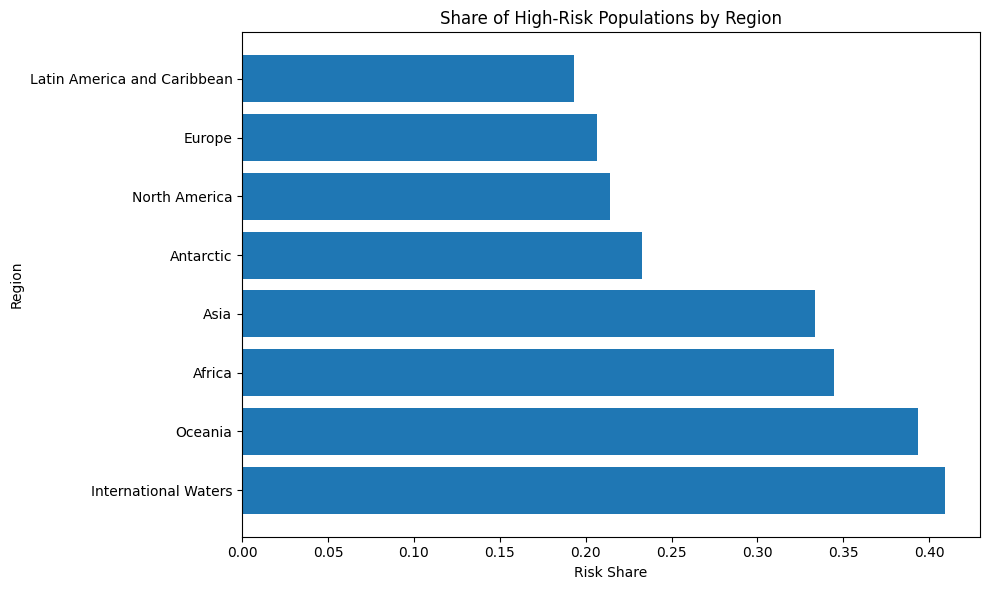

In [17]:
region_risk = region_risk.sort_values(
    "Risk_Share",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    region_risk["Region"],
    region_risk["Risk_Share"]
)

plt.title("Share of High-Risk Populations by Region")
plt.xlabel("Risk Share")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [18]:
risk_subset = spatial_data[
    spatial_data["Risk_Category"].isin(
        ["Critical decline", "High decline"]
    )
]

heatmap_data = pd.crosstab(
    risk_subset["Class"],
    risk_subset["Region"]
)

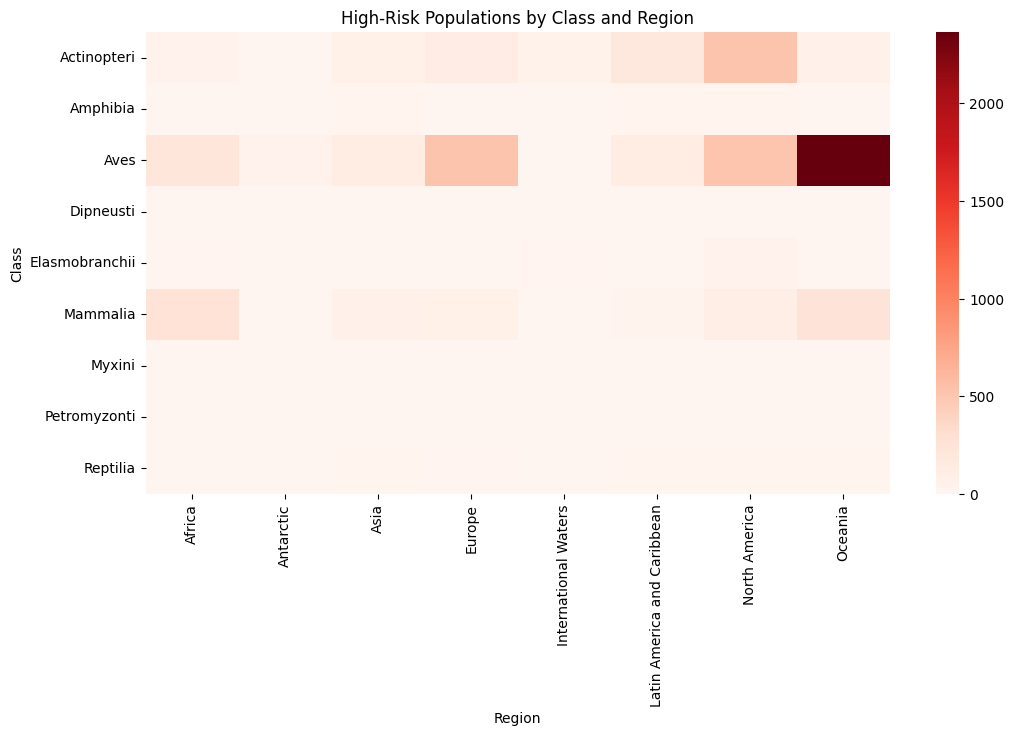

In [26]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap="Reds"
)

plt.title(
    "High-Risk Populations by Class and Region"
)

plt.show()

In [25]:
all_counts = pd.crosstab(
    spatial_data["Class"],
    spatial_data["Region"]
)

risk_counts = pd.crosstab(
    high_risk_data["Class"],
    high_risk_data["Region"]
)

risk_share_heatmap = (
    risk_counts
    .div(all_counts)
    .fillna(0)
)

<Axes: xlabel='Region', ylabel='Class'>

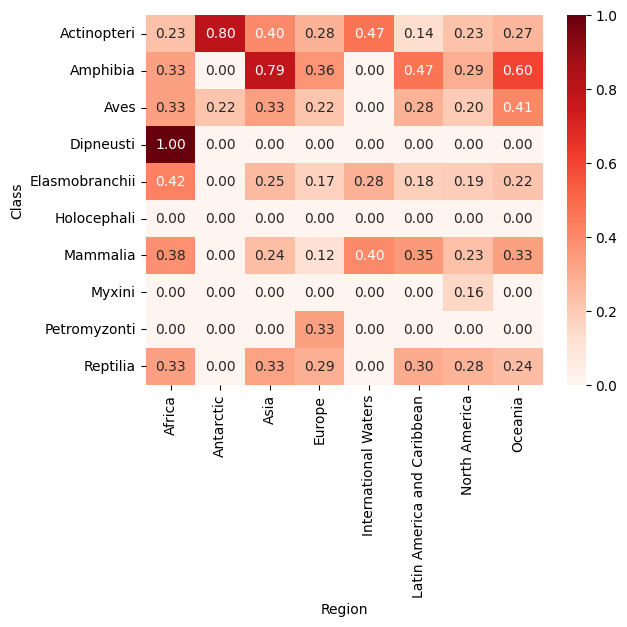

In [28]:
sns.heatmap(
    risk_share_heatmap,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

In [33]:
risk_share_heatmap_filtered = (
    risk_counts
    .div(all_counts)
    .where(all_counts >= 20)
    .fillna(0)
)

<Axes: xlabel='Region', ylabel='Class'>

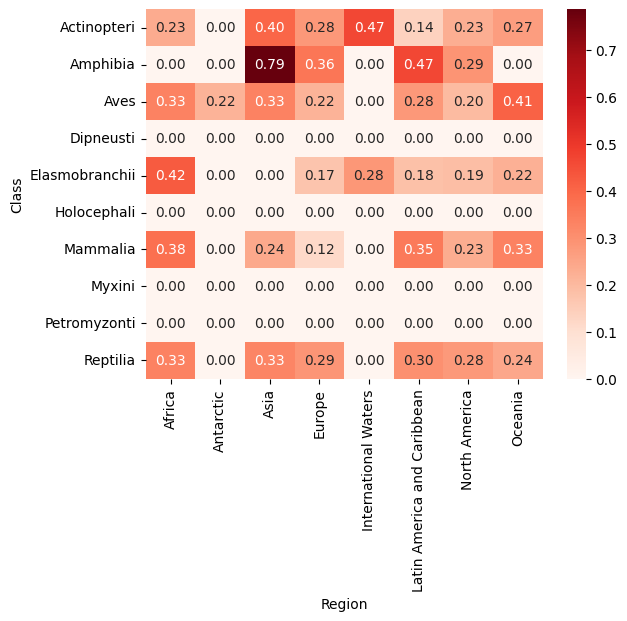

In [34]:

sns.heatmap(
    risk_share_heatmap_filtered,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

In [22]:
high_risk_data = spatial_data[
    spatial_data["Risk_Category"].isin(
        ["Critical decline", "High decline"]
    )
].copy()

spatial_data["Lat_Bin"] = (
    spatial_data["Latitude"] // 10
) * 10

spatial_data["Lon_Bin"] = (
    spatial_data["Longitude"] // 10
) * 10

In [23]:
hotspots = (
    high_risk_data
    .groupby(["Lat_Bin", "Lon_Bin"])
    .size()
    .reset_index(name="High_Risk_Count")
)

In [24]:

hotspots.sort_values(
    "High_Risk_Count",
    ascending=False
).head(20)

,Lat_Bin,Lon_Bin,High_Risk_Count
56,-30.0,150.0,616
38,-40.0,140.0,585
181,40.0,-70.0,297
37,-40.0,130.0,296
67,-20.0,120.0,206
69,-20.0,140.0,174
39,-40.0,150.0,164
22,-50.0,140.0,160
55,-30.0,140.0,146
35,-40.0,110.0,128


In [29]:
all_counts = pd.crosstab(
    spatial_data["Class"],
    spatial_data["Region"]
)

all_counts

Region,Africa,Antarctic,Asia,Europe,International Waters,Latin America and Caribbean,North America,Oceania
Class,,,,,,,,
Actinopteri,184,10,199,446,103,1406,2290,209
Amphibia,3,0,28,22,0,58,79,15
Aves,643,180,399,2408,0,483,2570,5793
Dipneusti,1,0,0,0,0,0,0,0
Elasmobranchii,33,3,4,23,46,22,239,27
Holocephali,0,0,0,0,0,0,4,0
Mammalia,686,9,275,697,5,96,445,744
Myxini,0,0,0,0,0,0,19,0
Petromyzonti,0,0,0,3,0,0,2,0
